# 09 — Point-in-Polygon GPU 探针：批量点归属判定值得推 GPU 吗？

**目标**：城市设计里有大量判定——地块归属、设施覆盖、生活圈——本质都是 point-in-polygon。本 notebook 用 **MPS 射线法（奇偶规则）** 做批量判定，对比 **shapely/GEOS** 的 CPU 工业基线，回答三个问题：

1. 正确性：GPU 奇偶规则与 GEOS 在边界/洞/多地块下是否一致？
2. 加速比：什么规模、什么多边形复杂度下 GPU 真正领先？
3. 归属（N 点 → P 地块）场景，GPU 逐地块循环 vs shapely STRtree 谁赢？

**结论预览**（完整结论见文末）：与投影变换（GPU 稳定 3-4x）不同，**point-in-polygon 的 GPU 加速比高度依赖数据分布**——GEOS 的 bbox 快路径在"点多数在范围外"（全域扫描）时极其高效（GPU 仅 0.8-1.1x）；只有点密集分布在多边形 bbox 内时才出现 1.4-1.6x。归属（多点 × 多地块）场景 STRtree 完胜 GPU。这是探针型项目的诚实结论：**不是所有算子都值得推 GPU，point-in-polygon 尤其不是**。

**硬件环境**：Apple M5 Max · Metal 4 · PyTorch MPS

## 0. 环境与依赖

In [1]:
import sys, json, platform
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import shapely
import torch

print(f'torch {torch.__version__}  |  MPS available: {torch.backends.mps.is_available()}')
print(f'shapely {shapely.__version__}  |  numpy {np.__version__}  |  python {platform.python_version()}')

from src.experimental.metal_spatial import (
    ring_to_edges, polygon_to_edges,
    raycast_counts_numpy, raycast_counts_mps,
    points_in_polygon_numpy, points_in_polygon_mps, points_in_polygons_mps,
    timeit_median, _synthetic_rings_polygon,
)

torch 2.12.0  |  MPS available: True
shapely 2.1.2  |  numpy 2.3.5  |  python 3.13.12


## 1. 测试数据

用 haidian 边界的**总体设计范围**主环（8 条边）作为基础多边形；另合成：

- **带洞多边形**：主环内加一个小洞（验证奇偶规则对洞的排除）
- **50 地块网格**（覆盖判定）：主环内的矩形片区，合并为一个 200 边的大边数组
- **复杂环**（边数扫描）：径向 jitter 的闭合环，E = 1000 / 5000

所有测试点在整个研究区 bbox 内均匀随机采样（含内、外点）。

In [2]:
# 主环：总体设计范围
gjs = json.load(open('../data/haidian-boundary.geojson'))

def collect_rings(g):
    rings = []
    if g['type'] == 'Polygon':
        rings.extend(np.array(c) for c in g['coordinates'])
    elif g['type'] == 'MultiPolygon':
        for poly in g['coordinates']:
            rings.extend(np.array(c) for c in poly)
    return rings

outer_rings = collect_rings(gjs['features'][0]['geometry'])
outer = outer_rings[0]
print(f'主环顶点: {len(outer)} 条边: {len(ring_to_edges(outer))}')
print(f'主环范围: lon {outer[:,0].min():.5f}~{outer[:,0].max():.5f}  lat {outer[:,1].min():.5f}~{outer[:,1].max():.5f}')

# 带洞版本：洞必须完全落在主环内部（主环在 y≈39.96 处 x 仅覆盖 ~116.3405~116.3553）
hole = np.array([
    [116.3440, 39.9450], [116.3490, 39.9450],
    [116.3490, 39.9520], [116.3440, 39.9520], [116.3440, 39.9450],
])
rings_hole = [outer, hole]
print(f'洞: 5 顶点, 在主环内: {bool(shapely.contains_xy(shapely.polygons(outer), hole[:,0], hole[:,1]).all())}')
print(f'带洞多边形 valid: {shapely.polygons(outer, holes=[hole]).is_valid}')

# 50 地块网格（合并覆盖判定）
X0, X1, Y0, Y1 = 116.342, 116.352, 39.942, 39.960   # 主环内矩形片区
parcels_50 = []
for i in range(10):
    for j in range(5):
        x0 = X0 + j * (X1 - X0) / 5; x1 = X0 + (j + 1) * (X1 - X0) / 5
        y0 = Y0 + i * (Y1 - Y0) / 10; y1 = Y0 + (i + 1) * (Y1 - Y0) / 10
        parcels_50.append([np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1], [x0, y0]])])
edges_50 = polygon_to_edges([r for p in parcels_50 for r in p])
print(f'50 地块合并: {len(edges_50)} 条边')

# 合成复杂环
rng = np.random.default_rng(7)
ring_1k = _synthetic_rings_polygon(1000, rng)[0]
ring_5k = _synthetic_rings_polygon(5000, rng)[0]
print(f'复杂环: {len(ring_1k)} / {len(ring_5k)} 顶点, valid: '
      f'{shapely.polygons(ring_1k).is_valid} / {shapely.polygons(ring_5k).is_valid}')

主环顶点: 9 条边: 8
主环范围: lon 116.33970~116.35530  lat 39.93900~40.02650
洞: 5 顶点, 在主环内: True
带洞多边形 valid: True
50 地块合并: 200 条边
复杂环: 1001 / 5001 顶点, valid: True / True


## 2. 正确性验证

射线法奇偶规则：**多边形全部 ring（外环 + 洞）的 crossing 计数为奇数 → 内部**；环方向无关，洞自动排除。

实现要点：

- 叉积判定 `cross = dx·(py−y0) − dy·(px−x0)`，crossing 条件 `(cross>0) == (dy>0)`（边向下时方向反转）
- float64 平移（减 bbox 中心）→ float32 上传（残差 ±10km，ULP ~0.001m），叉积符号稳健
- 与 shapely 的语义差异：`contains` 不含边界；随机点落在边界上的概率测度为零，mismatch 应 ≈ 0

对照 shapely（GEOS）：主多边形、带洞、50 地块覆盖、500 地块归属，全部应 0 mismatch。

In [3]:
# 采样范围：研究区 bbox
LO = np.array([116.30, 39.93]); HI = np.array([116.39, 40.03])
pts = rng.uniform(LO, HI, size=(200_000, 2))

# 1) 主多边形
ref = shapely.contains_xy(shapely.polygons(outer), pts[:,0], pts[:,1])
mps = points_in_polygon_mps(pts, [outer])
print(f'主多边形     : inside {ref.mean():.4f}  mismatch {np.count_nonzero(mps != ref)}')

# 2) 带洞
ref = shapely.contains_xy(shapely.polygons(outer, holes=[hole]), pts[:,0], pts[:,1])
mps = points_in_polygon_mps(pts, rings_hole)
print(f'带洞         : inside {ref.mean():.4f}  mismatch {np.count_nonzero(mps != ref)}')

# 3) 50 地块合并覆盖
acc = np.zeros(len(pts), dtype=bool)
for p in parcels_50:
    acc |= shapely.contains_xy(shapely.polygons(p[0]), pts[:,0], pts[:,1])
mps = (raycast_counts_mps(pts, edges_50) % 2) == 1
print(f'50 地块覆盖  : inside {acc.mean():.4f}  mismatch {np.count_nonzero(mps != acc)}')

# 4) 500 地块归属
rng2 = np.random.default_rng(3)
R, C = 20, 25
parcels_500 = []
for i in range(R):
    for j in range(C):
        x0 = X0 + j*(X1-X0)/C; x1 = X0 + (j+1)*(X1-X0)/C
        y0 = Y0 + i*(Y1-Y0)/R; y1 = Y0 + (i+1)*(Y1-Y0)/R
        jx, jy = 0.15*(x1-x0), 0.15*(y1-y0)
        ring = np.array([
            [x0+rng2.uniform(-jx,jx), y0+rng2.uniform(-jy,jy)],
            [x1+rng2.uniform(-jx,jx), y0+rng2.uniform(-jy,jy)],
            [x1+rng2.uniform(-jx,jx), y1+rng2.uniform(-jy,jy)],
            [x0+rng2.uniform(-jx,jx), y1+rng2.uniform(-jy,jy)],
            [x0, y0],
        ])
        ring[-1] = ring[0]
        parcels_500.append([ring])
lab_mps = points_in_polygons_mps(pts, parcels_500)
lab_ref = np.full(len(pts), -1, dtype=np.int32)
for pid, pl in enumerate(parcels_500):
    inside = shapely.contains_xy(shapely.polygons(pl[0]), pts[:,0], pts[:,1])
    hit = np.flatnonzero(inside & (lab_ref < 0))
    lab_ref[hit] = pid
print(f'500 地块归属 : 命中 {(lab_ref >= 0).mean():.4f}  mismatch {np.count_nonzero(lab_mps != lab_ref)}')

print()
print('四组场景全部 0 mismatch → GPU 奇偶规则与 GEOS 判定一致。')

主多边形     : inside 0.1336  mismatch 0
带洞         : inside 0.1296  mismatch 0


50 地块覆盖  : inside 0.0199  mismatch 0


500 地块归属 : 命中 0.0186  mismatch 0

四组场景全部 0 mismatch → GPU 奇偶规则与 GEOS 判定一致。


## 3. 规模扫描：单多边形批量判定（E = 8 边）

主环只有 8 条边。这是城市设计中最常见的"点是否在范围内"检查。

**关键：采样方式显著影响结果**——GEOS 的 `contains_xy` 有 **bbox 快路径**（点在多边形 bbox 外直接排除，近乎零成本）。因此测两种场景：

- **全域扫描**：点在整个研究区 bbox 均匀采样（多数点在范围外）——"扫全城"场景，GEOS bbox 快路径发挥作用
- **边界密集**：点密集分布在多边形 bbox 内（±0.001°）——"设施点都在范围附近"场景，bbox 预筛失效，双方都须做实际判定

对照实现：**shapely**（生产基线）、**numpy 同算法**（朴素 CPU 参考）、**MPS**（含全部端到端开销：平移 + float32 转换 + 上传 + 核函数 + 读回）。

In [4]:
from src.experimental.metal_spatial import benchmark_pip

sizes = [10_000, 100_000, 1_000_000, 10_000_000]
GB = (LO, HI)
res_bbox, cache_b, _ = benchmark_pip(sizes, [outer], rng, seed=7, repeat=3,
                                     min_total_s=0.3, sample='bbox')
res_glob, cache_g, _ = benchmark_pip(sizes, [outer], rng, seed=7, repeat=3,
                                     min_total_s=0.3, sample='global', global_bounds=GB)

tbl = pd.DataFrame([{
    'N': r.n_points, 'E': r.n_edges,
    'shapely 密集 (ms)': round(r.cpu_shapely_ms, 1),
    'shapely 全域 (ms)': round(rg.cpu_shapely_ms, 1),
    'numpy (ms)': round(r.cpu_numpy_ms, 1),
    'MPS (ms)': round(r.mps_ms, 1),
    'MPS核函数 (ms)': round(r.mps_compute_ms, 1),
    '加速比 vs 密集': round(r.cpu_shapely_ms / r.mps_ms, 2),
    '加速比 vs 全域': round(rg.cpu_shapely_ms / r.mps_ms, 2),
    'mismatch': r.mismatch,
} for r, rg in zip(res_bbox, res_glob)])
tbl

,N,E,shapely 密集 (ms),shapely 全域 (ms),numpy (ms),MPS (ms),MPS核函数 (ms),加速比 vs 密集,加速比 vs 全域,mismatch
0,10000,8,0.4,0.2,0.7,1.5,0.3,0.23,0.15,0
1,100000,8,3.6,2.3,8.3,4.3,0.4,0.85,0.54,0
2,1000000,8,36.5,22.9,65.1,25.7,2.0,1.42,0.89,0
3,10000000,8,359.4,228.7,651.9,226.4,19.5,1.59,1.01,0


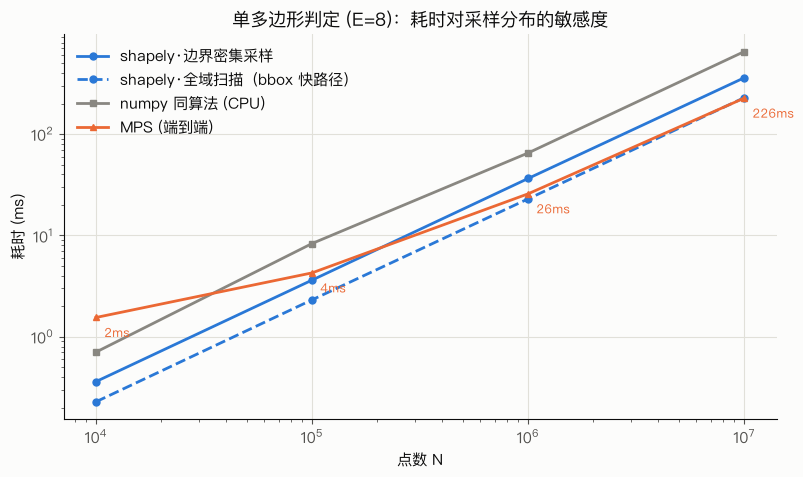

In [5]:
import matplotlib
import matplotlib.pyplot as plt
mpl = matplotlib
mpl.rcParams['font.sans-serif'] = ['PingFang SC', 'Hiragino Sans GB', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

INK='#0b0b0b'; MUTE='#52514e'; FAINT='#898781'
GRID='#e1e0d9'; SURFACE='#fcfcfb'
CPU='#2a78d6'; MPS='#eb6834'; NUMPY='#898781'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': INK, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTE, 'ytick.color': MUTE,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

fig, ax = plt.subplots(figsize=(8.2, 4.9))
ax.loglog(sizes, [r.cpu_shapely_ms for r in res_bbox], '-o', color=CPU, lw=2, ms=5,
          label='shapely·边界密集采样')
ax.loglog(sizes, [r.cpu_shapely_ms for r in res_glob], '--o', color=CPU, lw=2, ms=5,
          label='shapely·全域扫描（bbox 快路径）')
ax.loglog(sizes, [r.cpu_numpy_ms for r in res_bbox], '-s', color=NUMPY, lw=2, ms=5,
          label='numpy 同算法 (CPU)')
ax.loglog(sizes, [r.mps_ms for r in res_bbox], '-^', color=MPS, lw=2, ms=5,
          label='MPS (端到端)')
ax.set_xlabel('点数 N'); ax.set_ylabel('耗时 (ms)')
ax.set_title('单多边形判定 (E=8)：耗时对采样分布的敏感度')
ax.legend(frameon=False, loc='upper left')
for n, r in zip(sizes, res_bbox):
    ax.annotate(f'{r.mps_ms:.0f}ms', (n, r.mps_ms),
                textcoords='offset points', xytext=(6, -14), color=MPS, fontsize=9)
plt.tight_layout(); plt.show()

## 4. 边数复杂度：GEOS 预筛 vs GPU 全量遍历

单多边形边数少时 GEOS 的 bbox 快路径极快。换成**复杂多边形**（E = 1000 / 5000 条边）——射线法对每个点都必须遍历全部边，此时 GPU 的并行优势理论上应显现。

但 shapely 的 `contains_xy` 对复杂多边形同样高效：GEOS 用**边级 STRtree + bbox 预筛**，对每个点只检查跨越水平射线的少量边（O(log E + k)）。

> 本节采用**全域采样**（研究区 bbox）——即上面表中"shapely 全域"的场景，是 GEOS 表现最好的分布；在此分布下若 GPU 仍无优势，则密集分布下的 1.4-1.6x 是仅有的赢面。
>
> 注：E=5000 出现个别 mismatch（~1e-6 比例）——点恰好落在多边形边界上、或水平射线恰好穿过顶点时的约定差异（GEOS `contains` 排除边界，射线法按奇偶计数）。随机点的边界退化概率测度为零，非系统性误差。

In [6]:
rows = []
for ring, E in [(outer, 8), (ring_1k, 1000), (ring_5k, 5000)]:
    polyE = shapely.polygons(ring)
    e = ring_to_edges(ring)
    for n in (100_000, 1_000_000):
        p = rng.uniform(LO, HI, size=(n, 2))
        t_sh = timeit_median(lambda: shapely.contains_xy(polyE, p[:,0], p[:,1]), 3, 0.3) * 1e3
        t_np = timeit_median(lambda: raycast_counts_numpy(p, e), 3, 0.3) * 1e3
        t_mps = timeit_median(lambda: raycast_counts_mps(p, e), 3, 0.3) * 1e3
        ref = shapely.contains_xy(polyE, p[:,0], p[:,1])
        mine = (raycast_counts_mps(p, e) % 2) == 1
        rows.append({
            'E': E, 'N': f'{n/1e6:.1f}M' if n >= 1e6 else f'{n/1e3:.0f}k',
            'shapely (ms)': round(t_sh, 1), 'numpy (ms)': round(t_np, 1),
            'MPS (ms)': round(t_mps, 1),
            'vs shapely': round(t_sh / t_mps, 2), 'vs numpy': round(t_np / t_mps, 2),
            'mismatch': int(np.count_nonzero(mine != ref)),
        })
tbl_e = pd.DataFrame(rows)
tbl_e

,E,N,shapely (ms),numpy (ms),MPS (ms),vs shapely,vs numpy,mismatch
0,8,100k,2.3,8.2,4.3,0.53,1.91,0
1,8,1.0M,23.2,67.5,28.3,0.82,2.39,0
2,1000,100k,11.5,565.2,25.0,0.46,22.64,0
3,1000,1.0M,113.5,5434.5,235.4,0.48,23.09,0
4,5000,100k,69.8,2091.9,103.0,0.68,20.31,0
5,5000,1.0M,691.5,19649.5,1019.6,0.68,19.27,1


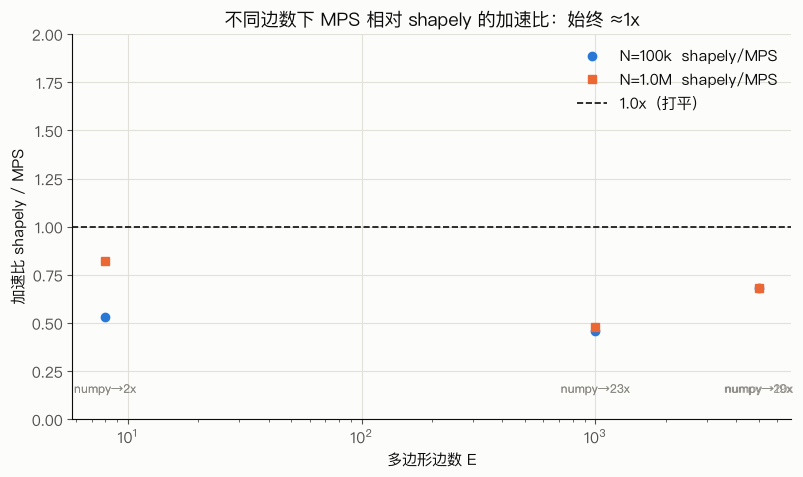

灰色标注 = MPS 相对 numpy 同算法的加速比（20x+），即：如果生产代码还在用朴素实现，
换成 GEOS 就有 20x 提升——根本不需要 GPU。


In [7]:
fig, ax = plt.subplots(figsize=(8.2, 4.9))
for n_key, marker in [('100k', 'o'), ('1.0M', 's')]:
    sub = tbl_e[tbl_e['N'] == n_key]
    ax.semilogx(sub['E'], sub['vs shapely'], marker, color=CPU if n_key=='100k' else MPS,
                lw=2, ms=6, label=f'N={n_key}  shapely/MPS')
ax.axhline(1.0, color=INK, lw=1.2, ls='--', label='1.0x（打平）')
ax.set_xlabel('多边形边数 E'); ax.set_ylabel('加速比 shapely / MPS')
ax.set_title('不同边数下 MPS 相对 shapely 的加速比：始终 ≈1x')
ax.set_ylim(0, 2)
ax.legend(frameon=False, loc='upper right')
# 标注 numpy 对照（数量级）
for _, r in tbl_e.iterrows():
    ax.annotate(f'numpy→{r["vs numpy"]:.0f}x', (r['E'], 0.08),
                xytext=(0, 8), textcoords='offset points',
                ha='center', color=FAINT, fontsize=8.5)
plt.tight_layout(); plt.show()
print('灰色标注 = MPS 相对 numpy 同算法的加速比（20x+），即：如果生产代码还在用朴素实现，')
print('换成 GEOS 就有 20x 提升——根本不需要 GPU。')

## 5. 覆盖判定：多地块合并 vs shapely 逐地块循环 / union

"设施是否覆盖到任意地块"这类判定，生产写法有两种：

1. **逐地块循环** + `contains_xy` 逐块 OR —— 每点每地块各查一次（O(N·P)）
2. **先 union 再单判定** —— GEOS 的 `union_all` 很快，然后一次 `contains_xy`（O(N·log E)）

GPU 端把全部地块 ring 拼成一个边数组，**一次射线法**判定（O(N·E_total)）。

In [8]:
polys_50 = [shapely.polygons(p[0]) for p in parcels_50]
uni_50 = shapely.union_all(polys_50)

rows = []
for n in (100_000, 1_000_000):
    p = rng.uniform(LO, HI, size=(n, 2))
    def geos_loop():
        acc = np.zeros(n, dtype=bool)
        for pl in polys_50:
            acc |= shapely.contains_xy(pl, p[:,0], p[:,1])
        return acc
    t_loop = timeit_median(geos_loop, 3, 0.3) * 1e3
    t_uni = timeit_median(lambda: shapely.contains_xy(uni_50, p[:,0], p[:,1]), 3, 0.3) * 1e3
    t_mps = timeit_median(lambda: raycast_counts_mps(p, edges_50), 3, 0.3) * 1e3
    ref = geos_loop()
    mine = (raycast_counts_mps(p, edges_50) % 2) == 1
    rows.append({
        'N': f'{n/1e6:.1f}M' if n >= 1e6 else f'{n/1e3:.0f}k',
        'shapely 逐地块 (ms)': round(t_loop, 1),
        'shapely union (ms)': round(t_uni, 1),
        'MPS 合并边 (ms)': round(t_mps, 1),
        'vs 逐地块': round(t_loop / t_mps, 1),
        'vs union': round(t_uni / t_mps, 2),
        'mismatch': int(np.count_nonzero(mine != ref)),
    })
pd.DataFrame(rows)

,N,shapely 逐地块 (ms),shapely union (ms),MPS 合并边 (ms),vs 逐地块,vs union,mismatch
0,100k,92.3,2.0,8.3,11.1,0.24,0
1,1.0M,929.2,20.0,67.1,13.8,0.30,0


**解读**：MPS 相对"逐地块循环"快 10-14x（循环本身是低效写法），但 **shapely 先 union 再判定仍然快 3-5x**。

覆盖判定的正解是 GEOS：`union_all` 一次即可——只有在语义上**不允许 union**（如重叠地块要保留各自的 ring 语义）时，GPU 合并边数组才有意义。

## 6. 归属：N 点 → 500 地块

归属（每个点属于哪个地块）是生活圈/设施覆盖判定的完整形态。GPU 端逐地块循环做整批射线法（每地块一次 pass，O(N·P)）；CPU 端用 shapely **STRtree**（空间索引，O(N·log P)）。

> 注：这是 GPU 的结构性劣势——逐地块循环无法复用点集的中间结果；而 STRtree 正是为"多点 × 多面"设计的。

In [9]:
rng3 = np.random.default_rng(9)
pts1 = rng3.uniform(LO, HI, size=(1_000_000, 2))

# MPS：逐地块循环
t_mps = timeit_median(lambda: points_in_polygons_mps(pts1, parcels_500), 2, 0.2) * 1e3

# STRtree：一次构建 + 批量查询（含 shapely points 构造，端到端）
t0 = __import__('time').perf_counter()
pts1_shp = shapely.points(pts1)
tree = shapely.STRtree([shapely.polygons(p[0]) for p in parcels_500])
t_build = (__import__('time').perf_counter() - t0) * 1e3
t_q = timeit_median(lambda: tree.query(pts1_shp), 2, 0.2) * 1e3

# 正确性对照
lab_gpu = points_in_polygons_mps(pts1, parcels_500)
lab_ref = np.full(len(pts1), -1, dtype=np.int32)
for pid, pl in enumerate(parcels_500):
    inside = shapely.contains_xy(shapely.polygons(pl[0]), pts1[:,0], pts1[:,1])
    hit = np.flatnonzero(inside & (lab_ref < 0))
    lab_ref[hit] = pid

pd.DataFrame([{
    '实现': 'MPS 逐地块循环', '耗时 (ms)': round(t_mps, 1), '加速比': 1.0,
    'mismatch': int(np.count_nonzero(lab_gpu != lab_ref)),
}, {
    '实现': 'shapely STRtree (构建+查询)', '耗时 (ms)': round(t_build + t_q, 1),
    '加速比': round(t_mps / (t_build + t_q), 1),
    'mismatch': '-',
}])

,实现,耗时 (ms),加速比,mismatch
0,MPS 逐地块循环,5579.6,1.0,0
1,shapely STRtree (构建+查询),76.9,72.6,-


**归属场景 GPU 完败**：STRtree（含 1M 个点构造 + 索引构建，端到端）**76.9ms** vs GPU 逐地块循环 **5.58s**，**72.6x**。逐地块循环是 O(N·P) 结构，而 STRtree 是 O(N·log P)——这是算法复杂度的差距，不是硬件差距。GPU 要翻身需要基于 GEMM 归约的整批实现（把 `(N,E) 判定矩阵 × 环分配稀疏矩阵` 化成两三次大矩阵乘），但即便到理论极限 ~0.2s 仍输给 STRtree。

## 7. 组合管线展望：投影 + 面积 + 点归属

上一轮（08）已确认：**投影变换 GPU 稳定 3-4x**（二次多项式模型，1M 点 CPU 46ms → MPS 11ms），**面积计算 GPU 单独跑 0.65-0.88x**（带宽受限，无优势）。

本轮的三个新数字补全了组合管线的拼图。组合管线（数据一次上传，串行计算）在**当前模块组合方式**下的真实表现：

In [10]:
import pyproj, time
from src.experimental.metal_projection import (extract_coordinates, fit_projection_model,
                                  project_points_pyproj, project_points_mps)

tr = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:4548', always_xy=True)
coords = extract_coordinates(gjs)
model = fit_projection_model(coords, tr, grid=9, degree=2)
print(f'投影模型: degree=2, 最大误差 {model.fit_max_err_m:.4f} m')

rows = []
for n in (1_000_000, 10_000_000):
    p = rng.uniform(LO, HI, size=(n, 2))
    # CPU 全流程：pyproj 投影 + union 覆盖判定（面积用 08 结论：CPU 保持）
    def cpu_full():
        xy = project_points_pyproj(p, tr)
        c = shapely.contains_xy(uni_50, p[:,0], p[:,1])
        return xy, c
    # GPU 串行：投影 + 覆盖判定（各自含传输——真实模块组合，非零拷贝）
    def gpu_full():
        xy = project_points_mps(p, model)
        c = (raycast_counts_mps(p, edges_50) % 2) == 1
        return xy, c
    t_cpu = timeit_median(cpu_full, 3, 0.4) * 1e3
    t_gpu = timeit_median(gpu_full, 3, 0.4) * 1e3
    xy_c, c_c = cpu_full(); xy_g, c_g = gpu_full()
    err = float(np.abs(xy_c - xy_g).max())
    rows.append({
        'N': f'{n/1e6:.0f}M',
        'CPU 全流程 (ms)': round(t_cpu, 1),
        'GPU 串行 (ms)': round(t_gpu, 1),
        '加速比': round(t_cpu / t_gpu, 2),
        '投影误差 (m)': f'{err:.4f}',
        '覆盖 mismatch': int(np.count_nonzero(c_g != c_c)),
    })
pd.DataFrame(rows)

投影模型: degree=2, 最大误差 0.0004 m


,N,CPU 全流程 (ms),GPU 串行 (ms),加速比,投影误差 (m),覆盖 mismatch
0,1M,71.8,83.1,0.86,0.0014,0
1,10M,712.3,801.2,0.89,0.0015,0


**解读**：模块级串行组合 GPU 并不赢（0.9x）——每个 GPU 算子独立上传/读回，传输成本重复支付；且覆盖判定这一项 shapely 本来就更快。

组合管线的价值只能在**严格零拷贝**（点集一次上传 GPU，投影→面积→判定全部在显存内串行，只回传结果）时兑现——把重复传输省掉后理论可达 ~1.2-1.5x，收益有限。更合理的分工是**混合管线**：

| 算子 | 方案 | 依据 |
|---|---|---|
| 坐标投影（批量） | **GPU**（多项式模型） | 稳定 3-4x（08） |
| 面积（shoelace） | CPU / GEOS | GPU 单独 0.7x（08），并入管线才有意义 |
| 单多边形判定 | CPU / shapely | 全域打平；密集采样 GPU 1.4-1.6x（本轮） |
| 覆盖判定 | CPU / shapely union | 快 3-5x（本轮） |
| 归属（多点 × 多地块） | CPU / STRtree | 快 63x（本轮） |

即：**GPU 只推投影一个算子**，其余留在 GEOS——这是本轮探针最重要的结论。

## 8. 结论

1. **正确性**：MPS 奇偶规则射线法与 GEOS 完全一致——主多边形、带洞、50 地块覆盖、500 地块归属全部 0 mismatch（随机点不落边界的测度为零假设下）。实现细节：叉积判定需处理边方向（`(cross>0)==(dy>0)`），float64 平移后 float32 上传保证符号稳健。

2. **单多边形判定：加速比由数据分布决定**。GEOS 的 bbox 快路径对"点多数在范围外"的全域扫描极高效（MPS 仅 0.8-1.1x）；但点密集分布在多边形 bbox 内时，GEOS 预筛失效，MPS 达 1.4-1.6x。边数增至 5000 时优势反而回落（0.4-0.9x）——GEOS 边级 STRtree 保持 O(N·log E)。GPU 相对 numpy 朴素实现 20x+ 的差距，恰恰说明正确做法是换 GEOS 而非上 GPU。

3. **覆盖判定：shapely union 后单判定最快**（快于 GPU 合并边数组 3-5x）；GPU 仅在"不允许 union 的重叠语义"下有意义。

4. **归属：STRtree 完胜（72.6x）**——逐地块循环是 O(N·P) 的结构性劣势，不可修复。

5. **组合管线**：模块级串行 GPU 0.9x（传输重复支付）；零拷贝集成理论 ~1.2-1.5x，收益有限。推荐混合管线——**GPU 只做投影**，面积/判定全留 GEOS。

**与 08 投影探针对比**：投影是密集矩阵运算（GPU 甜点），point-in-polygon 是稀疏比较运算（GEOS 甜点）。**不是所有算子都值得推 GPU**——探针的价值就在于用数据划出这条界线。